In [1]:
#Import Libraries

import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score

In [6]:
#Load Trained Model

model = joblib.load("D:/customer-churn-capstone/models/churn_model.pkl")

In [7]:
print(type(model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [8]:
#Load Test Data

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

y_test = y_test.squeeze()

In [9]:
#Generate Prediction Probabilities

y_prob = model.predict_proba(X_test)[:, 1]

In [10]:
#Calculate ROC-AUC Score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9724208375893769


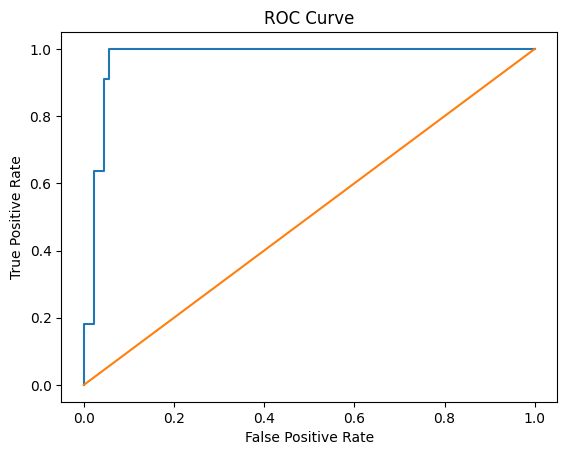

In [11]:
#Plot ROC Curve

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [12]:
X_train = pd.read_csv("../data/processed/X_train.csv")

feature_columns = X_train.columns.tolist()

os.makedirs("../models", exist_ok=True)

joblib.dump(feature_columns, "../models/feature_columns.pkl")

['../models/feature_columns.pkl']

In [13]:
loaded_columns = joblib.load("../models/feature_columns.pkl")

print("Number of Features:", len(loaded_columns))

Number of Features: 9


Loaded trained Logistic Regression model.

Generated prediction probabilities.

Computed ROC-AUC score.

Plotted ROC curve for visual performance evaluation.

Saved feature column order for deployment safety.

Verified saved artifacts.